In [1]:
import awkward as ak
import numpy as np
import time
import coffea
import uproot
import hist
import vector
import json
print("awkward version ", ak.__version__)
print("coffea version ", coffea.__version__)
from coffea import util, processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema, BaseSchema
from collections import defaultdict
import pickle
import glob
import matplotlib.pyplot as plt

awkward version  1.10.3
coffea version  0.7.21


In [2]:
# f = uproot.open('root://cmsxrootd.fnal.gov//store/mc/RunIISummer20UL16NanoAODv9/QCD_Pt_1400to1800_TuneCP5_13TeV_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/120000/4068147B-3494-A843-91E0-D0E58E4AB8CD.root')
# f = uproot.open('root://cmsxrootd.fnal.gov//store/mc/RunIISummer20UL16NanoAODv9/QCD_Pt_1000to1400_TuneCP5_13TeV_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/120000/B0DD6724-2C13-6E4F-8C4E-4C8C616839E2.root')
# f = uproot.open('root://cmsxrootd.fnal.gov//store/mc/RunIISummer20UL16NanoAODv9/QCD_Pt-15to7000_TuneCP5_Flat2018_13TeV_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/130000/1C569D85-60AE-7D43-B42B-6D6FD1D66CC7.root')

In [3]:
# f["Events"].keys()

In [4]:
# f["Events"]["Generator_binvar"].arrays()

In [5]:
# f["Events"]["Generator_scalePDF"].arrays()

In [24]:
fileset = {"2016":[], "2016APV":[]}

with open('data/nanoAOD/QCD.json') as json_file:
    data = json.load(json_file)
    fileset['2016'] += ['root://cmsxrootd//'+data['2016']['1800to2400'][i] for i in range(len(data))]
    fileset['2016APV'] += ['root://cmsxrootd//'+data['2016APV']['1800to2400'][i] for i in range(len(data))]
print(fileset)

{'2016': ['root://cmsxrootd///store/mc/RunIISummer20UL16NanoAODv9/QCD_Pt_1800to2400_TuneCP5_13TeV_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/120000/34ABBFC7-6ED2-134D-AD3C-78E1339F137A.root', 'root://cmsxrootd///store/mc/RunIISummer20UL16NanoAODv9/QCD_Pt_1800to2400_TuneCP5_13TeV_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/120000/60B607CD-8E1E-AF40-8DDE-2655634B2FD1.root', 'root://cmsxrootd///store/mc/RunIISummer20UL16NanoAODv9/QCD_Pt_1800to2400_TuneCP5_13TeV_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/120000/79E6D9C1-2337-1B4B-A8EC-9035C6080BBA.root', 'root://cmsxrootd///store/mc/RunIISummer20UL16NanoAODv9/QCD_Pt_1800to2400_TuneCP5_13TeV_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/120000/7CA7BC6D-19E3-4B46-A172-376D9CB8C710.root', 'root://cmsxrootd///store/mc/RunIISummer20UL16NanoAODv9/QCD_Pt_1800to2400_TuneCP5_13TeV_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/120000/C165F58E-362D-3945-8770-7F38E2DDC0CD.root', 'root://cmsxrootd///store/mc/RunIISummer20UL16Nano

In [25]:
class Counter(processor.ProcessorABC):
    def __init__(self ):
        weights_axis = hist.axis.Regular(100, -2, 2, name="w", label="Weights")
        pt_axis = hist.axis.Regular( 700, 0, 7000, 
                                     name="pt", label="Pt")

#        pt_axis = hist.axis.Variable( [0,10,20,30,40,50,60,70,80,90,
#                                       100,110,120,130,140,150,160,170,180,190,
#                                       200,210,220,230,240,250,260,270,280,290,
#                                       300,310,320,330,340,350,360,370,380,390,
#                                       400,410,420,430,440,450,460,470,480,490,
#                                       500,510,520,530,540,550,560,570,580,590,
#                                       1000,2000,3000,4000,5000,6000,7000], 
#                                     name="pt", label="Pt")
        dataset_axis = hist.axis.StrCategory([], growth=True, name="dataset", label="Primary dataset")
        
        ### Plots of things during the selection process / for debugging with fine binning
        h_w = hist.Hist(dataset_axis, weights_axis, pt_axis, storage="weight", label="Counts")
        self.hists = {
            "w":h_w
        }
        
        self.means_stddevs = defaultdict()
    
    @property
    def accumulator(self):
        return self.hists

    
    # we will receive a NanoEvents instead of a coffea DataFrame
    def process(self, events):
        dataset = events.metadata['dataset']
        
        ht = ak.sum( events["Jet"].pt, axis=1 )
        htgood = ht > 1400.
        events = events[htgood]
        
        avg = np.average(events.genWeight)
        stddev = np.std(events.genWeight)

        print("weights ", np.log(events["Generator"].weight/np.log(10.)))
        print("binvar  ", events["Generator"].binvar)
        self.hists['w'].fill( dataset=dataset, w=np.log(events["Generator"].weight)/np.log(10.), pt=events["Generator"].binvar )
        weirdweight = ((events["Generator"].weight - avg) / stddev > 2)

        weird = weirdweight
        
        print(events["Generator"].weight[weird] )
        print(events["Generator"].binvar[weird] )
                
        return self.hists

    
    def postprocess(self, accumulator):
        return accumulator
    
    
    

In [26]:
run = processor.Runner(
    executor = processor.FuturesExecutor(compression=None, workers=2),
    schema=NanoAODSchema,
    chunksize=1000000,
    maxchunks=None
)

output = run(
    fileset,
    "Events",
    processor_instance=Counter(),
)

Output()

Output()

weights  [-0.834, -0.834, -0.834, -0.834, -0.834, ... -0.834, -0.834, -0.834, -0.834, -0.834]
binvar   [1.95e+03, 1.87e+03, 1.87e+03, 1.8e+03, ... 1.98e+03, 1.97e+03, 1.98e+03, 1.81e+03]


/opt/conda/lib/python3.8/site-packages/awkward/_connect/_numpy.py:195: RuntimeWarning: invalid value encountered in divide
  result = getattr(ufunc, method)(


[]
[]
weights  [-0.834, -0.834, -0.834, -0.834, -0.834, ... -0.834, -0.834, -0.834, -0.834, -0.834]
binvar   [2.1e+03, 1.9e+03, 1.9e+03, 2.13e+03, ... 2.03e+03, 2.25e+03, 1.85e+03, 1.84e+03]


/opt/conda/lib/python3.8/site-packages/awkward/_connect/_numpy.py:195: RuntimeWarning: invalid value encountered in divide
  result = getattr(ufunc, method)(


[]
[]
weights  [-0.834, -0.834, -0.834, -0.834, -0.834, ... -0.834, -0.834, -0.834, -0.834, -0.834]
binvar   [2.39e+03, 1.87e+03, 1.93e+03, 2.03e+03, ... 1.93e+03, 2.1e+03, 2.07e+03, 2.21e+03]
[]
[]
weights  [-0.834, -0.834, -0.834, -0.834, -0.834, ... -0.834, -0.834, -0.834, -0.834, -0.834]
binvar   [2.09e+03, 1.92e+03, 1.99e+03, 1.86e+03, ... 1.97e+03, 1.94e+03, 1.83e+03, 1.91e+03]
[]
[]
weights  [-0.834, -0.834, -0.834, -0.834, -0.834, ... -0.834, -0.834, -0.834, -0.834, -0.834]
binvar   [1.82e+03, 1.86e+03, 1.8e+03, 2.03e+03, ... 1.97e+03, 2.18e+03, 1.95e+03, 2e+03]
[]
[]
weights  [-0.834, -0.834, -0.834, -0.834, -0.834, ... -0.834, -0.834, -0.834, -0.834, -0.834]
binvar   [1.9e+03, 2.04e+03, 1.82e+03, 2.16e+03, ... 2.04e+03, 2.25e+03, 1.99e+03, 1.94e+03]
[]
[]
weights  [-0.834, -0.834, -0.834, -0.834, -0.834, ... -0.834, -0.834, -0.834, -0.834, -0.834]
binvar   [1.95e+03, 2.11e+03, 1.94e+03, 2.07e+03, ... 2.08e+03, 2.21e+03, 1.83e+03, 1.94e+03]
[]
[]
weights  [-0.834, -0.834, -0.8

In [27]:
output

{'w': Hist(
   StrCategory(['2016APV', '2016'], growth=True, name='dataset', label='Primary dataset'),
   Regular(100, -2, 2, name='w', label='Weights'),
   Regular(700, 0, 7000, name='pt', label='Pt'),
   storage=Weight()) # Sum: WeightedSum(value=5.23196e+06, variance=5.23196e+06)}

In [28]:
w, x, y = output['w'][0,:,:].to_numpy()
print(x)

[-2.   -1.96 -1.92 -1.88 -1.84 -1.8  -1.76 -1.72 -1.68 -1.64 -1.6  -1.56
 -1.52 -1.48 -1.44 -1.4  -1.36 -1.32 -1.28 -1.24 -1.2  -1.16 -1.12 -1.08
 -1.04 -1.   -0.96 -0.92 -0.88 -0.84 -0.8  -0.76 -0.72 -0.68 -0.64 -0.6
 -0.56 -0.52 -0.48 -0.44 -0.4  -0.36 -0.32 -0.28 -0.24 -0.2  -0.16 -0.12
 -0.08 -0.04  0.    0.04  0.08  0.12  0.16  0.2   0.24  0.28  0.32  0.36
  0.4   0.44  0.48  0.52  0.56  0.6   0.64  0.68  0.72  0.76  0.8   0.84
  0.88  0.92  0.96  1.    1.04  1.08  1.12  1.16  1.2   1.24  1.28  1.32
  1.36  1.4   1.44  1.48  1.52  1.56  1.6   1.64  1.68  1.72  1.76  1.8
  1.84  1.88  1.92  1.96  2.  ]


Text(0, 0.5, 'binvar')

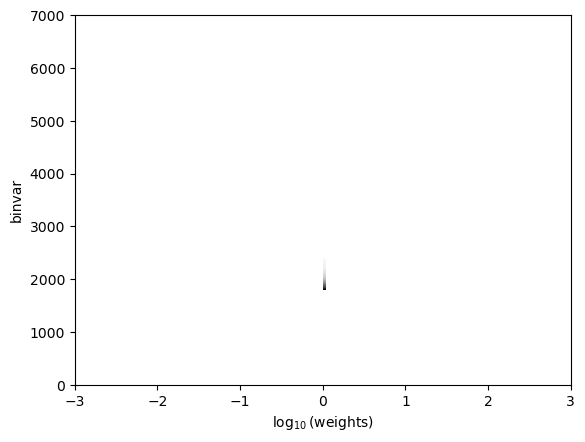

In [29]:
mesh = plt.pcolormesh(x,y, w.T, cmap="Greys")#, vmin=1e-8, vmax=1e-3 )
# plt.ylim(1000,1400)
plt.xlim(-3,3)
plt.xlabel(r'$\log_{10}\left(\mathrm{weights}\right)$')
plt.ylabel('binvar')
# plt.axline((-22, 600), (-5, 600))
# plt.xscale('symlog')

(1700.0, 2500.0)

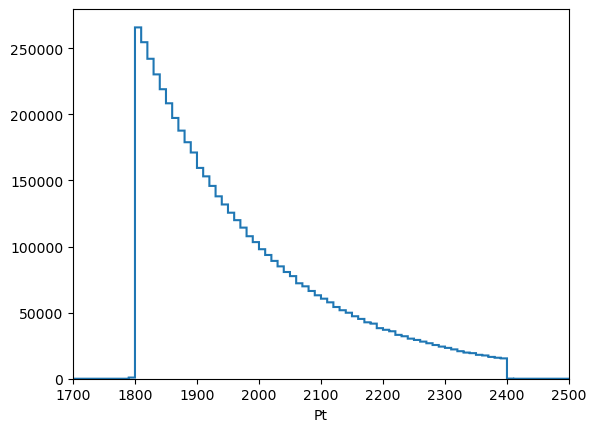

In [30]:
output['w'].project("pt").plot()
#plt.yscale("log")
plt.xlim(1700,2500)